## Import Data 

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
data = pd.read_excel(r"D:\Downloads\Udemy-PY\Sales-Data-Analysis.xlsx")

In [5]:
data

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,NaN,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,NaN,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,NaN,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,NaN,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...,...
250,NaN,10709,2022-12-28 00:00:00,Sides & Other,4.99,200.400802,Drive-thru,Gift Card,Walter Muller,Berlin
251,NaN,10710,2022-12-29 00:00:00,Burgers,12.99,754.426482,Drive-thru,Gift Card,Walter Muller,Berlin
252,NaN,10711,2022-12-29 00:00:00,Chicken Sandwiches,9.95,281.407035,Drive-thru,Gift Card,Walter Muller,Berlin
253,NaN,10712,2022-12-29 00:00:00,Fries,3.49,630.372493,Drive-thru,Gift Card,Walter Muller,Berlin


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  255 non-null    object 
 2   Unnamed: 2  255 non-null    object 
 3   Unnamed: 3  255 non-null    object 
 4   Unnamed: 4  255 non-null    object 
 5   Unnamed: 5  255 non-null    object 
 6   Unnamed: 6  255 non-null    object 
 7   Unnamed: 7  255 non-null    object 
 8   Unnamed: 8  255 non-null    object 
 9   Unnamed: 9  255 non-null    object 
dtypes: float64(1), object(9)
memory usage: 20.1+ KB


### 1. Delete unwanted/ NaN Columns

In [7]:
data.drop(columns = "Unnamed: 0", inplace = True)

In [8]:
data.head() #Removed one column

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin


### 2. Change the Column names

In [9]:
data.loc[0]

Unnamed: 1          Order ID
Unnamed: 2              Date
Unnamed: 3           Product
Unnamed: 4             Price
Unnamed: 5          Quantity
Unnamed: 6     Purchase Type
Unnamed: 7    Payment Method
Unnamed: 8           Manager
Unnamed: 9              City
Name: 0, dtype: object

In [10]:
data.columns

Index(['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='object')

In [11]:
data.columns = data.loc[0]

In [12]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin


In [13]:
data.drop(0, inplace = True) #Removed the first row permanently 

In [14]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
5,10456,2022-11-08 00:00:00,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin


### 3. Remove extra spaces in Manager column

In [15]:
data['Manager'].unique()

array(['Tom      Jackson', '       Pablo Perez', 'Joao    Silva',
       'Walter Muller', 'Remy    Monet', 'Remy Monet',
       '       Remy Monet', 'Remy     Monet', 'Pablo Perez',
       'Pablo   Perez', 'Pablo  Perez', 'Pablo    Perez', 'Joao Silva',
       'Tom Jackson'], dtype=object)

In [16]:
data['Manager'] = data['Manager'].str.strip().str.replace(r'\s+',' ', regex= True)

### 4. Remove all duplicates

In [17]:
data.describe()

C:\Users\hmmuz\AppData\Local\Temp\ipykernel_1228\3175101911.py:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  data.describe()


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
count,254,254,254,254.00,254.000000,254,254,254,254
unique,254,53,5,7.00,29.000000,3,3,5,5
top,10452,2022-11-09 00:00:00,Chicken Sandwiches,12.99,200.400802,Online,Credit Card,Tom Jackson,London
freq,1,5,52,52.00,49.000000,107,120,75,75


#### No duplicates here, as count and unique are equal!

In [18]:
data[data.duplicated()]

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City


In [19]:
data.drop_duplicates(inplace = True)

### 5. Converting Datatypes of Columns 

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 1 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order ID        254 non-null    object
 1   Date            254 non-null    object
 2   Product         254 non-null    object
 3   Price           254 non-null    object
 4   Quantity        254 non-null    object
 5   Purchase Type   254 non-null    object
 6   Payment Method  254 non-null    object
 7   Manager         254 non-null    object
 8   City            254 non-null    object
dtypes: object(9)
memory usage: 18.0+ KB


In [21]:
data.Quantity = data.Quantity.astype(float)

In [22]:
data.Date = pd.to_datetime(data.Date)

## Analyzing Data

### a). Most Preferred method for Payment? 

In [23]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid


In [24]:
data['Payment Method'].unique()

array([' Gift Card', ' Credit Card', ' Cash'], dtype=object)

In [25]:
data['Payment Method'].value_counts()

Payment Method
Credit Card    120
Cash            76
Gift Card       58
Name: count, dtype: int64

In [26]:
data['Payment Method'].value_counts(normalize =True)

Payment Method
Credit Card    0.472441
Cash           0.299213
Gift Card      0.228346
Name: proportion, dtype: float64

In [27]:
data['Payment Method'].value_counts(normalize = True)*100    #to get value in percentage

Payment Method
Credit Card    47.244094
Cash           29.921260
Gift Card      22.834646
Name: proportion, dtype: float64

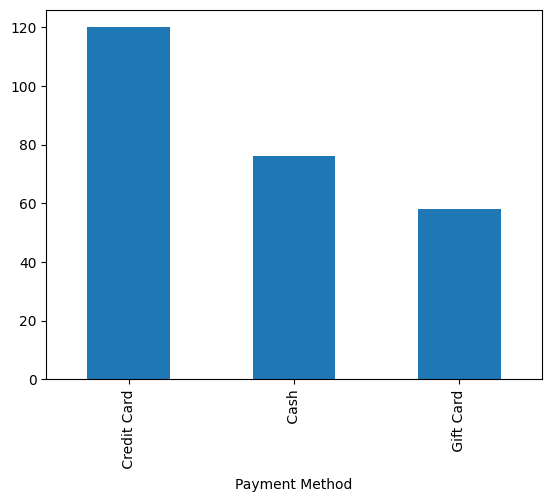

In [28]:
data['Payment Method'].value_counts().plot(kind = 'bar') ;

### b). Most Selling Product?
  - by Quantity
  - by Revenue

i- By Quantity

In [29]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid


In [30]:
data.groupby('Product')['Quantity'].sum()

Product
Beverages             34983.050847
Burgers               29022.324865
Chicken Sandwiches    11135.678392
Fries                 32034.383954
Sides & Other          9819.639279
Name: Quantity, dtype: float64

In [31]:
most_quantity = data.groupby('Product')['Quantity'].sum().sort_values(ascending= False)

In [34]:
most_quantity = most_quantity.reset_index()
most_quantity

,index,Product,Quantity
0,0,Beverages,34983.050847
1,1,Fries,32034.383954
2,2,Burgers,29022.324865
3,3,Chicken Sandwiches,11135.678392
4,4,Sides & Other,9819.639279


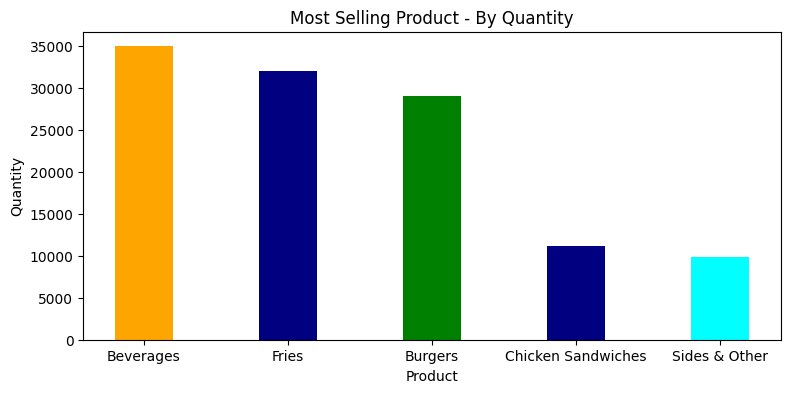

In [45]:
plt.figure(figsize = (9,4))
plt.bar(most_quantity['Product'], most_quantity['Quantity'], color =['orange', 'navy', 'green', 'navy', 'cyan'], width = 0.4) 
plt.title('Most Selling Product - By Quantity')
plt.xlabel('Product')
plt.ylabel('Quantity');

ii- By Revenue

In [47]:
data['Revenue'] = data['Quantity']*data['Price']

In [48]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
1,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London,2000.0
2,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid,2200.0


In [54]:
data.groupby("Product")['Revenue'].sum().sort_values(ascending= False)

Product
Burgers                    377000.0
Fries                 125674.498567
Chicken Sandwiches     114639.19598
Beverages                  103200.0
Sides & Other               49000.0
Name: Revenue, dtype: object

In [62]:
most_revenue = data.groupby('Product')['Revenue'].sum().sort_values(ascending= False)
most_revenue

Product
Burgers                    377000.0
Fries                 125674.498567
Chicken Sandwiches     114639.19598
Beverages                  103200.0
Sides & Other               49000.0
Name: Revenue, dtype: object

In [66]:
most_revenue = most_revenue.reset_index()

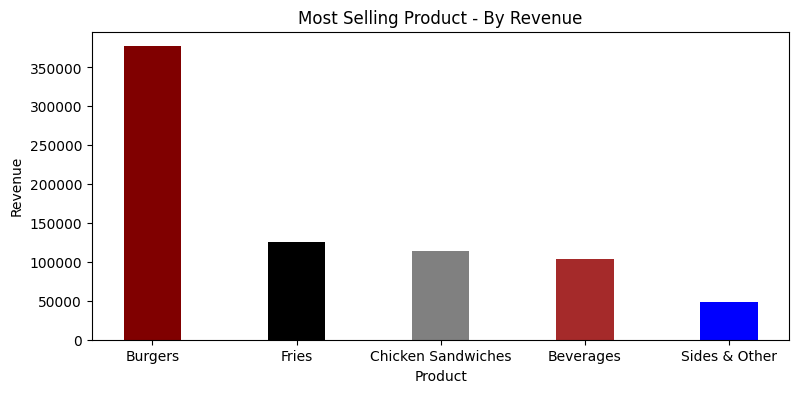

In [74]:
plt.figure(figsize = (9,4))
plt.bar(most_revenue['Product'], most_revenue['Revenue'], color = ['maroon', 'black', 'gray', 'brown', 'blue'], width= 0.4)
plt.title('Most Selling Product - By Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue');


### c). Which Manager earned maximum Revenue?

In [78]:
data.Manager.unique()

array(['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller',
       'Remy Monet'], dtype=object)

In [79]:
data.groupby('Manager')['Revenue'].sum().sort_values(ascending = False)

Manager
Joao Silva       241713.694547
Tom Jackson           211200.0
Pablo Perez           136200.0
Walter Muller         100600.0
Remy Monet             79800.0
Name: Revenue, dtype: object

### d). Date wise Revenue?


In [80]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
1,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London,2000.0
2,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid,2200.0


In [84]:
data['Date'].dtype

dtype('<M8[ns]')

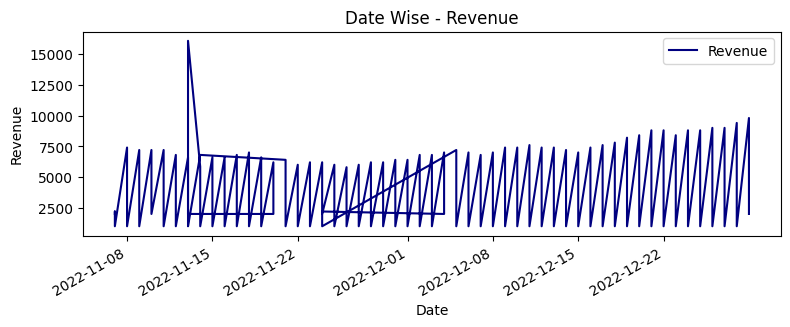

In [89]:
data.plot('Date', 'Revenue', color =['navy'], figsize = (9,3))
plt.title('Date Wise - Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue');

### e). What is the average Revenue of November and December?

In [90]:
data['Month'] =  data['Date'].dt.month

In [91]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
1,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London,2000.0,11
2,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid,2200.0,11


In [96]:
m11 = data[data['Month'] == 11]

In [97]:
m11

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
1,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London,2000.0,11
2,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid,2200.0,11
3,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon,1000.0,11
4,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin,7400.0,11
5,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin,2000.0,11
...,...,...,...,...,...,...,...,...,...,...,...
109,10568,2022-11-30,Beverages,2.95,677.966102,Online,Credit Card,Tom Jackson,London,2000.0,11
110,10569,2022-11-30,Sides & Other,4.99,200.400802,Online,Credit Card,Tom Jackson,London,1000.0,11
128,10537,2022-11-24,Fries,3.49,630.372493,Drive-thru,Credit Card,Pablo Perez,Madrid,2200.0,11
129,10538,2022-11-24,Beverages,2.95,745.762712,Drive-thru,Credit Card,Pablo Perez,Madrid,2200.0,11


In [98]:
m11.Revenue.mean()

np.float64(2939.0592437808386)

In [99]:
m12 = data[data['Month'] == 12]

In [100]:
m12

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
111,10570,2022-12-01,Burgers,12.99,492.686682,Online,Credit Card,Tom Jackson,London,6400.0,12
112,10571,2022-12-01,Chicken Sandwiches,9.95,201.005025,Online,Credit Card,Tom Jackson,London,2000.0,12
113,10572,2022-12-01,Fries,3.49,573.065903,Online,Credit Card,Remy Monet,Paris,2000.0,12
114,10573,2022-12-01,Beverages,2.95,677.966102,Online,Credit Card,Remy Monet,Paris,2000.0,12
115,10574,2022-12-01,Sides & Other,4.99,200.400802,Online,Credit Card,Remy Monet,Paris,1000.0,12
...,...,...,...,...,...,...,...,...,...,...,...
250,10709,2022-12-28,Sides & Other,4.99,200.400802,Drive-thru,Gift Card,Walter Muller,Berlin,1000.0,12
251,10710,2022-12-29,Burgers,12.99,754.426482,Drive-thru,Gift Card,Walter Muller,Berlin,9800.0,12
252,10711,2022-12-29,Chicken Sandwiches,9.95,281.407035,Drive-thru,Gift Card,Walter Muller,Berlin,2800.0,12
253,10712,2022-12-29,Fries,3.49,630.372493,Drive-thru,Gift Card,Walter Muller,Berlin,2200.0,12


In [101]:
m12.Revenue.mean()

np.float64(3102.127659574468)

### f). What is Standard Deviation for Revenue & Quantity?

In [103]:
data['Quantity'].std()

np.float64(214.88955129185314)

In [104]:
data['Revenue'].std()

np.float64(2420.1241927718042)

### g). What is Variance for Revenue & Quantity?

In [105]:
data['Revenue'].var()

np.float64(5857001.108439377)

In [106]:
data['Quantity'].var()

np.float64(46177.51925441398)

### h). Is Revenue Increasing or Decreasing over time?

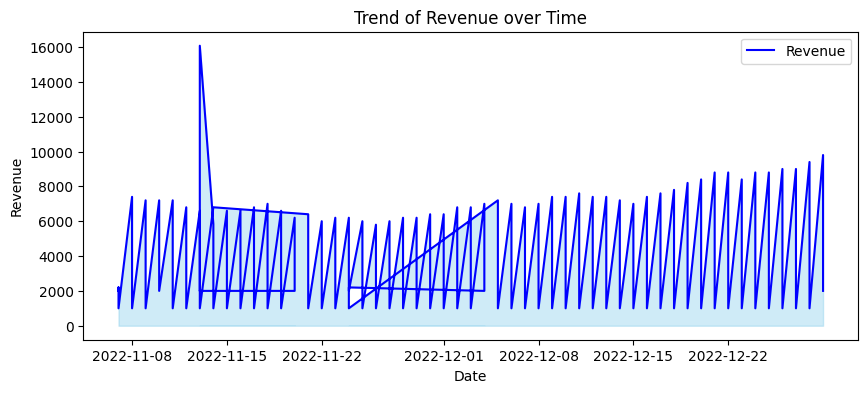

In [113]:
import matplotlib.pyplot as plt
data['Date'] = pd.to_datetime(data['Date'])
data['Revenue'] = pd.to_numeric(data['Revenue'], errors='coerce')
plt.figure(figsize = (10, 4))
plt.plot(data['Date'], data['Revenue'], color='blue', label='Revenue')
plt.fill_between(data['Date'], data['Revenue'], color='skyblue', alpha=0.4)
plt.title('Trend of Revenue over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

### h). Average Quantity sold and Average Revenue for each Product?

In [114]:
data.groupby('Product')['Revenue','Quantity'].agg({'Revenue' : 'mean', 'Quantity' : 'mean' })

IndexError: Column(s) Revenue already selected